In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
%matplotlib inline

df = pd.read_csv("sales_data.csv")

print("A random sample of 6 records:")
print(df.sample(n=6, random_state=1))

print("\nNumber of unique values in each column:")
print(df.nunique())

A random sample of 6 records:
    Product Region  Sales
17  Printer  South  32000
21   Laptop  South  51000
10   Mobile   East  42000
19   Mobile   West  39000
14  Printer   East  29000
20  Printer  North  31000

Number of unique values in each column:
Product     3
Region      4
Sales      30
dtype: int64


In [2]:
# ---------------- Distribution of the categories ----------------
print("Number of records for each Product:")
print(df["Product"].value_counts())

print("\nPercentage share of each Region:")
print((df["Region"].value_counts(normalize=True) * 100).round(2))

print("\nMemory used by each column (bytes):")
print(df.memory_usage(deep=True))

print("\nTotal memory used :", df.memory_usage(deep=True).sum(), "bytes")

Number of records for each Product:
Product
Laptop     10
Mobile     10
Printer    10
Name: count, dtype: int64

Percentage share of each Region:
Region
North    26.67
South    26.67
East     23.33
West     23.33
Name: proportion, dtype: float64

Memory used by each column (bytes):
Index       132
Product    1900
Region     1846
Sales       240
dtype: int64

Total memory used : 4118 bytes


In [3]:
# ---------------- Filtering using nlargest() and nsmallest() ----------------
print("Top 5 records by Sales:")
print(df.nlargest(5, "Sales"))

print("\nBottom 5 records by Sales:")
print(df.nsmallest(5, "Sales"))

print("\nHighest sale in each Region:")
print(df.loc[df.groupby("Region")["Sales"].idxmax()])

Top 5 records by Sales:
   Product Region  Sales
18  Laptop   East  58000
24  Laptop  North  56000
6   Laptop   East  55000
12  Laptop  North  52000
21  Laptop  South  51000

Bottom 5 records by Sales:
    Product Region  Sales
2   Printer   East  25000
23  Printer   West  26000
11  Printer   West  27000
8   Printer  North  28000
14  Printer   East  29000

Highest sale in each Region:
   Product Region  Sales
18  Laptop   East  58000
24  Laptop  North  56000
21  Laptop  South  51000
27  Laptop   West  49000


In [4]:
# ---------------- Group-wise filtering ----------------
# only those products whose average sales are above 40000 are retained
result = df.groupby("Product").filter(lambda g: g["Sales"].mean() > 40000)
print("Products whose average sales exceed 40000 :",
      list(result["Product"].unique()))
print("Number of records retained :", len(result))

# ---------------- Filtering with a variable inside query() ----------------
threshold = 50000
target_region = "North"
selected = df.query("Sales >= @threshold and Region == @target_region")
print("\nRecords with Sales >=", threshold, "in the", target_region, "region:")
print(selected)

Products whose average sales exceed 40000 : ['Laptop']
Number of records retained : 10

Records with Sales >= 50000 in the North region:
   Product Region  Sales
0   Laptop  North  50000
12  Laptop  North  52000
24  Laptop  North  56000


In [5]:
# ---------------- Cross-tabulation ----------------
ct = pd.crosstab(df["Product"], df["Region"], margins=True, margins_name="Total")
print("Cross-tabulation - number of records:")
print(ct)

# ---------------- Pivot table ----------------
pt = df.pivot_table(index="Product", columns="Region", values="Sales",
                    aggfunc=["sum", "mean"], margins=True, margins_name="Total")
print("\nPivot table - total and average sales:")
pt.round(2)

Cross-tabulation - number of records:
Region   East  North  South  West  Total
Product                                 
Laptop      2      3      2     3     10
Mobile      2      3      3     2     10
Printer     3      2      3     2     10
Total       7      8      8     7     30

Pivot table - total and average sales:


sum                                       mean                     \
Region     East   North   South    West    Total      East     North    South   
Product                                                                         
Laptop   113000  158000   99000  141000   511000  56500.00  52666.67  49500.0   
Mobile    86000  124000  108000   77000   395000  43000.00  41333.33  36000.0   
Printer   87000   59000   96000   53000   295000  29000.00  29500.00  32000.0   
Total    286000  341000  303000  271000  1201000  40857.14  42625.00  37875.0   

                             
Region       West     Total  
Product                      
Laptop   47000.00  51100.00  
Mobile   38500.00  39500.00  
Printer  26500.00  29500.00  
Total    38714.29  40033.33

In [6]:
# ---------------- Advanced descriptive measures ----------------
s = df["Sales"]

print("Mean                      :", round(s.mean(), 2))
print("Trimmed mean (10%)        :", round(stats.trim_mean(s, 0.1), 2))
print("Standard deviation        :", round(s.std(), 2))
print("Standard error of mean    :", round(s.sem(), 2))
print("Coefficient of variation  :", round(s.std() / s.mean() * 100, 2), "%")
print("Skewness                  :", round(s.skew(), 4))
print("Kurtosis                  :", round(s.kurt(), 4))
print("Inter-Quartile Range      :", s.quantile(0.75) - s.quantile(0.25))
print("Median Absolute Deviation :", round((s - s.median()).abs().median(), 2))

print()
if abs(s.skew()) < 0.5:
    print("INTERPRETATION : the distribution of Sales is nearly symmetric.")
elif s.skew() > 0:
    print("INTERPRETATION : the distribution of Sales is positively skewed.")
else:
    print("INTERPRETATION : the distribution of Sales is negatively skewed.")

Mean                      : 40033.33
Trimmed mean (10%)        : 39750.0
Standard deviation        : 9575.41
Standard error of mean    : 1748.22
Coefficient of variation  : 23.92 %
Skewness                  : 0.1896
Kurtosis                  : -1.0251
Inter-Quartile Range      : 15500.0
Median Absolute Deviation : 8000.0

INTERPRETATION : the distribution of Sales is nearly symmetric.


In [7]:
# ---------------- Group-wise descriptive statistics ----------------
print("Descriptive statistics of Sales for each Product:")
print(df.groupby("Product")["Sales"].describe().round(2))

print("\nDescriptive statistics of Sales for each Region:")
df.groupby("Region")["Sales"].describe().round(2)

Descriptive statistics of Sales for each Product:
         count     mean      std      min      25%      50%      75%      max
Product                                                                      
Laptop    10.0  51100.0  4175.32  45000.0  48250.0  50500.0  54250.0  58000.0
Mobile    10.0  39500.0  3027.65  35000.0  37250.0  39500.0  41750.0  44000.0
Printer   10.0  29500.0  3027.65  25000.0  27250.0  29500.0  31750.0  34000.0

Descriptive statistics of Sales for each Region:


,count,mean,std,min,25%,50%,75%,max
Region,,,,,,,,
East,7.0,40857.14,12641.58,25000.0,31000.0,42000.0,49500.0,58000.0
North,8.0,42625.00,9855.20,28000.0,37750.0,42000.0,50500.0,56000.0
South,8.0,37875.00,7548.65,30000.0,33500.0,35500.0,39750.0,51000.0
West,7.0,38714.29,9250.48,26000.0,32500.0,39000.0,46000.0,49000.0


In [8]:
# ---------------- Building a numeric feature set ----------------
# Additional numeric attributes are derived from the data so that the
# relationships between several numeric variables can be studied.
num = df.copy()
num["Product_Code"] = num["Product"].astype("category").cat.codes
num["Region_Code"] = num["Region"].astype("category").cat.codes
num["Product_Avg"] = num.groupby("Product")["Sales"].transform("mean")
num["Region_Share"] = (num["Sales"] /
                       num.groupby("Region")["Sales"].transform("sum") * 100).round(2)
num["Sales_Rank"] = num["Sales"].rank(ascending=False).astype(int)

cols = ["Sales", "Product_Code", "Region_Code", "Product_Avg",
        "Region_Share", "Sales_Rank"]
print("Numeric feature set:")
print(num[cols].head())

print("\nCovariance matrix:")
num[cols].cov().round(2)

Numeric feature set:
   Sales  Product_Code  Region_Code  Product_Avg  Region_Share  Sales_Rank
0  50000             0            1      51100.0         14.66           6
1  35000             1            2      39500.0         11.55          20
2  25000             2            0      29500.0          8.74          30
3  45000             0            3      51100.0         16.61          10
4  40000             1            1      39500.0         11.73          15

Covariance matrix:


,Sales,Product_Code,Region_Code,Product_Avg,Region_Share,Sales_Rank
Sales,91688505.75,-7448.28,-1431.03,80588505.75,29296.82,-84051.72
Product_Code,-7448.28,0.69,-0.07,-7448.28,-2.47,6.90
Region_Code,-1431.03,-0.07,1.22,744.83,-0.00,1.12
Product_Avg,80588505.75,-7448.28,744.83,80588505.75,26739.54,-74482.76
Region_Share,29296.82,-2.47,-0.00,26739.54,10.79,-26.79
Sales_Rank,-84051.72,6.90,1.12,-74482.76,-26.79,77.50


In [9]:
# ---------------- Pearson, Spearman and Kendall correlation ----------------
pearson = num[cols].corr(method="pearson")
spearman = num[cols].corr(method="spearman")
kendall = num[cols].corr(method="kendall")

print("Pearson correlation matrix:")
print(pearson.round(3))

print("\nComparison of the three methods for the pairs involving Sales:")
comparison = pd.DataFrame({
    "Pearson": pearson["Sales"],
    "Spearman": spearman["Sales"],
    "Kendall": kendall["Sales"],
}).round(4)
comparison

Pearson correlation matrix:
              Sales  Product_Code  Region_Code  Product_Avg  Region_Share  \
Sales         1.000        -0.937       -0.135        0.938         0.931   
Product_Code -0.937         1.000       -0.075       -0.999        -0.905   
Region_Code  -0.135        -0.075        1.000        0.075        -0.000   
Product_Avg   0.938        -0.999        0.075        1.000         0.907   
Region_Share  0.931        -0.905       -0.000        0.907         1.000   
Sales_Rank   -0.997         0.943        0.115       -0.942        -0.926   

              Sales_Rank  
Sales             -0.997  
Product_Code       0.943  
Region_Code        0.115  
Product_Avg       -0.942  
Region_Share      -0.926  
Sales_Rank         1.000  

Comparison of the three methods for the pairs involving Sales:


,Pearson,Spearman,Kendall
Sales,1.0000,1.0000,1.0000
Product_Code,-0.9367,-0.9433,-0.8305
Region_Code,-0.1351,-0.1172,-0.0966
Product_Avg,0.9375,0.9433,0.8305
Region_Share,0.9314,0.9408,0.8115
Sales_Rank,-0.9971,-1.0000,-1.0000


In [10]:
# ---------------- Testing the significance of the correlation ----------------
print("Correlation of Sales with the other attributes")
print("-" * 62)
print(f"{'Attribute':<16}{'r':>10}{'p-value':>12}{'Significant?':>16}")
print("-" * 62)

for c in ["Product_Code", "Region_Code", "Product_Avg", "Region_Share", "Sales_Rank"]:
    r, p = stats.pearsonr(num["Sales"], num[c])
    verdict = "Yes" if p < 0.05 else "No"
    print(f"{c:<16}{r:>10.4f}{p:>12.4f}{verdict:>16}")

print("-" * 62)
print("A p-value below 0.05 means the correlation is statistically significant.")

Correlation of Sales with the other attributes
--------------------------------------------------------------
Attribute                r     p-value    Significant?
--------------------------------------------------------------
Product_Code       -0.9367      0.0000             Yes
Region_Code        -0.1351      0.4767              No
Product_Avg         0.9375      0.0000             Yes
Region_Share        0.9314      0.0000             Yes
Sales_Rank         -0.9971      0.0000             Yes
--------------------------------------------------------------
A p-value below 0.05 means the correlation is statistically significant.


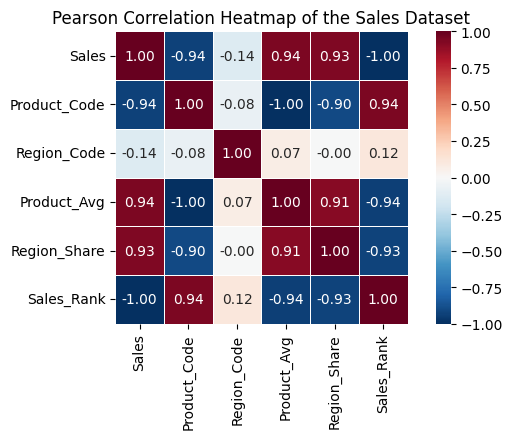

In [11]:
# ---------------- Visualising the correlation using a heatmap ----------------
plt.figure(figsize=(6.5, 4.5))
sns.heatmap(pearson, annot=True, fmt=".2f", cmap="RdBu_r",
            vmin=-1, vmax=1, linewidths=0.5, square=True)
plt.title("Pearson Correlation Heatmap of the Sales Dataset")
plt.tight_layout()
plt.show()

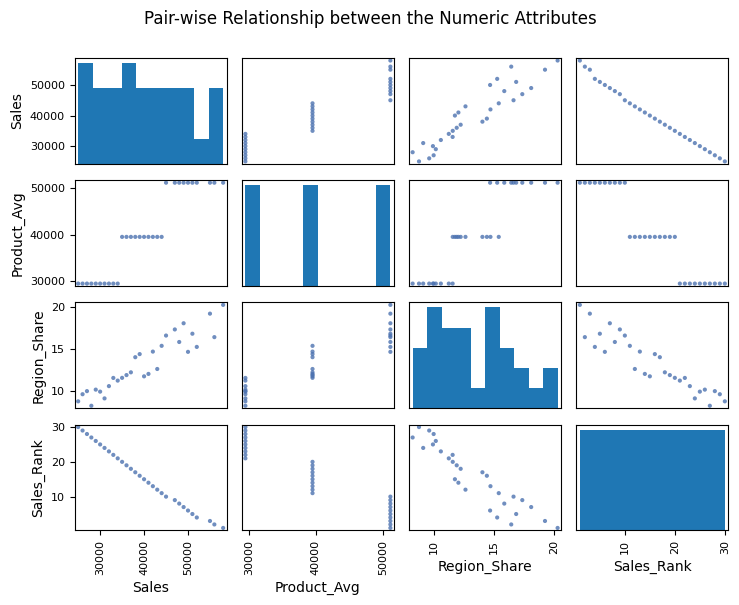

INTERPRETATION
Sales and Sales_Rank show a strong negative correlation because a higher
sales value always receives a smaller rank number, while Sales and
Region_Share show a strong positive correlation because a larger sale
contributes a larger share to the total of its region.


In [12]:
# ---------------- Pair-wise scatter plot ----------------
pd.plotting.scatter_matrix(num[["Sales", "Product_Avg", "Region_Share", "Sales_Rank"]],
                           figsize=(7.5, 6), diagonal="hist",
                           color="#4c72b0", alpha=0.8)
plt.suptitle("Pair-wise Relationship between the Numeric Attributes", y=1.0)
plt.tight_layout()
plt.show()

print("INTERPRETATION")
print("Sales and Sales_Rank show a strong negative correlation because a higher")
print("sales value always receives a smaller rank number, while Sales and")
print("Region_Share show a strong positive correlation because a larger sale")
print("contributes a larger share to the total of its region.")